# What Factors are Associated With the Popularity of Games on Steam?

This project focusses primarily on web scraping and data acquisition, using the `Steam Marketplace` as a real world data source. The objective is to demonstrate how data can be collected from a website using the `requests` library, parsed from HTML using `BeautifulSoup`, then cleaned and transformed into a `Pandas` dataframe so that the data is suitable for analysis. 

The Steam search results were used to collect information on 50 games, including their release date, price, supported platforms, review information and genres. The Steam Marketplace is dynamic and thus changes over time, so the data used in this work is subject to change and this project represents a snapshot of the Steam Marketplace at the time of collection. 

To demonstrate the use of the collected data, I performed EDA and investigated whether characteristics such as `price`, `release date`, `genre` or `platform` are associated with a game's popularity, for which I use `review_count` as a simple proxy and the target variable. 

It's important to note that the analysis is secondary to the data collection, and is intended to demonstrate data cleaning, transformation, visualisation and basic statistical analysis rather than to produce generalisable conclusions about the Steam Marketplace.

## Project Dependencies

In [106]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from scipy.stats import spearmanr

## Data Scraping

### Data Request and Parsing

Before beginning the data scraping we should first define our variables.

The `target variable` is `popularity`, but there is no such variable on the Steam page, so instead we will use the number of reviews as a measure of a game's popularity. \
The explanatory variables used for EDA will include factors like:
- price
- release_date
- review_score
- genre
- platform

These variables will allow us to investigate what factors are associated with popularity in the Steam marketplace. 

Now we will begin with the data scraping. I will use the `requests` library to send a request to the Steam search results page and retrieve its HTML content. I will then check that the request was successful by checking its status code.

In [107]:
url = "https://store.steampowered.com/search/?sort_by=Reviews_DESC&ignore_preferences=1&hwtype=0&category1=998&supportedlang=english&ndl=1"
response = requests.get(url)
print(response.status_code)

200


The response request returns a status code of 200, indicating that the Steam page was successfully retrieved.

The HTML code that was retrieved from Steam will now be parsed using `BeautifulSoup` which allows individual elements within the HTML to be extracted. 

First, I identify the HTML containers that correspond to individual game listings then loop through each listing to extract the variables defined earlier, including `release_date`, `price`, `platform` and `review_information`. 

Platform availability is extracted by examining the HTML classes associated with each platform, allowing games with multiple supported platforms to be captured. The review information is retained in its raw HTML form at this stage, as each entry for review_information contains multiple variables that will be extracted using string processing techniques during data cleaning. 

In order to extract a game's genre, I had to create an additional URL request as the genre of each game is not listed in the Steam search results, but instead on each game's own unique page. A second `BeautifulSoup` object is therefore created to extract the genre of each game. 

The extracted information is stored as a dictionary that is then converted into a pandas dataframe called `games_df`, which I will use to perform EDA to demonstrate how scraped data can be used for analysis. 

Finally, I use `join` on the `platform` and `genres` lists to create comma-separated strings, allowing for each game to be represented as a single observation in the dataframe. 

In [108]:
#initialize soup
soup = BeautifulSoup(response.text, "html.parser")


# find all of the html containers for each game
games = soup.find_all('a', class_="search_result_row")
#print the number of games 
print(len(games))

# create empty list to store the games and their data 
data = []

#loop through games and use soup to extract the variable for each game
for game in games:
    # Title
    title = game.find('span', class_='title').text.strip()
    # Release date
    release_date = game.find('div', class_='search_released').text.strip()
    # URL
    url = game['href']
    # App ID
    app_id = game['data-ds-appid']
    # Price
    price = game.find('div', class_='discount_final_price').text.strip()
    # Platforms
    platform = game.find('div', class_='search_platforms')
    platforms = platform.find_all('span')
    platform_names = []

    for p in platforms:
        classes = p.get('class', [])

        for class_name in classes:
            if class_name in ['win', 'mac', 'linux']:
                platform_names.append(str(class_name))
    # Review information
    review = game.find('span', class_='search_review_summary')
    review_info = review['data-tooltip-html']


    # game url 
    game_url = game['href']
    game_response = requests.get(game_url)
    game_soup = BeautifulSoup(game_response.text, 'html.parser')
    # genre
    genres = game_soup.select('a[href*="/genre/"]') 
    game_genres = []
    for genre in genres:
        game_genres.append(genre.text.strip())



    data.append({
        'title': title,
        'release_date': release_date,
        'url': url,
        'app_id': app_id,
        'price': price,
        'review_info': review_info,
        'platforms': platform_names,
        'genres': game_genres})
# Create a dataframe out of the scraped data

games_df = pd.DataFrame(data)
pd.set_option('display.max_colwidth', None)
games_df.head()
# Join the platforms into one string
games_df['platforms'] = games_df['platforms'].apply(', '.join)
# Join the genres into one string
games_df['genres'] = games_df['genres'].apply(', '.join)

50


In [109]:
games_df.head()

,title,release_date,url,app_id,price,review_info,platforms,genres
0,A Short Hike,"30 Jul, 2019",https://store.steampowered.com/app/1055540/A_Short_Hike/?snr=1_7_7_230_150_1,1055540,£5.79,"Overwhelmingly Positive<br>99% of the 12,543 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac, linux","Indie Games, Adventure, Indie"
1,The WereCleaner,"7 May, 2024",https://store.steampowered.com/app/2795000/The_WereCleaner/?snr=1_7_7_230_150_1,2795000,Free,"Overwhelmingly Positive<br>99% of the 8,409 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Indie Games, Action, Casual, Indie, Strategy, Free To Play"
2,Papa's Freezeria Deluxe,"31 Mar, 2023",https://store.steampowered.com/app/2291760/Papas_Freezeria_Deluxe/?snr=1_7_7_230_150_1,2291760,£4.99,"Overwhelmingly Positive<br>99% of the 9,426 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Strategy Games, Action, Casual, Indie, Simulation, Strategy"
3,Travellin Cats in Jingle Jam,"1 Dec, 2023",https://store.steampowered.com/app/2608050/Travellin_Cats_in_Jingle_Jam/?snr=1_7_7_230_150_1,2608050,Free,"Overwhelmingly Positive<br>99% of the 5,124 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Free To Play Games, Casual, Indie, Free To Play"
4,Poco,"20 May, 2025",https://store.steampowered.com/app/3454610/Poco/?snr=1_7_7_230_150_1,3454610,Free,"Overwhelmingly Positive<br>99% of the 6,923 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac","Free To Play Games, Adventure, Casual, Indie, Free To Play"


### Data Cleaning

Before starting cleaning, I will view the data types of each variable so that I know if anything will need changing.

In [110]:
games_df.dtypes

title           str
release_date    str
url             str
app_id          str
price           str
review_info     str
platforms       str
genres          str
dtype: object

Every variable is stored as a string data type. `release_date` will need to be converted to a date object and `price` will need to be stored as a float to enable numerical functions. I will also need to ensure that I store our target variable `review_count` as integers.

The scraped data is currently in its raw format, with several variables having multiple pieces of information within the same column. Therefore, the next step is to extract the information from these columns into their own variables and transform them into a format that can be used for analysis. I will also check that the data types are correct for each variable. 

The `review_info` variable contains several pieces of information that will need to be extracted into their own variables. First, I extracted the `review_score` of each game by splitting at `'<br>'` and selected the first element of the split. This allowed me to extract the review score of each game and store it inside of its own column called `review_score`. 

In [111]:
# extract the review score
games_df['review_score'] = games_df['review_info'].str.split('<br>').str[0]
games_df.head()


,title,release_date,url,app_id,price,review_info,platforms,genres,review_score
0,A Short Hike,"30 Jul, 2019",https://store.steampowered.com/app/1055540/A_Short_Hike/?snr=1_7_7_230_150_1,1055540,£5.79,"Overwhelmingly Positive<br>99% of the 12,543 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac, linux","Indie Games, Adventure, Indie",Overwhelmingly Positive
1,The WereCleaner,"7 May, 2024",https://store.steampowered.com/app/2795000/The_WereCleaner/?snr=1_7_7_230_150_1,2795000,Free,"Overwhelmingly Positive<br>99% of the 8,409 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Indie Games, Action, Casual, Indie, Strategy, Free To Play",Overwhelmingly Positive
2,Papa's Freezeria Deluxe,"31 Mar, 2023",https://store.steampowered.com/app/2291760/Papas_Freezeria_Deluxe/?snr=1_7_7_230_150_1,2291760,£4.99,"Overwhelmingly Positive<br>99% of the 9,426 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Strategy Games, Action, Casual, Indie, Simulation, Strategy",Overwhelmingly Positive
3,Travellin Cats in Jingle Jam,"1 Dec, 2023",https://store.steampowered.com/app/2608050/Travellin_Cats_in_Jingle_Jam/?snr=1_7_7_230_150_1,2608050,Free,"Overwhelmingly Positive<br>99% of the 5,124 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Free To Play Games, Casual, Indie, Free To Play",Overwhelmingly Positive
4,Poco,"20 May, 2025",https://store.steampowered.com/app/3454610/Poco/?snr=1_7_7_230_150_1,3454610,Free,"Overwhelmingly Positive<br>99% of the 6,923 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac","Free To Play Games, Adventure, Casual, Indie, Free To Play",Overwhelmingly Positive


Next, I will need to extract the number of reviews that each game has received, which will be used as the target variable and as a proxy for a game's popularity. This data is also stored inside of `review_info`, so I will again need to use text processing techniques to extract the variable.

I begin by extracting the value between `'of the'` and `'user'`, remove the comma used as a thousands separator, and then finally convert the result to an integer. I store this feature inside of the variable `review_count`.

In [112]:
games_df['review_count'] = games_df['review_info'].str.split('of the').str[1].str.split('user').str[0].str.replace(',', '').astype(int)
games_df.head()

,title,release_date,url,app_id,price,review_info,platforms,genres,review_score,review_count
0,A Short Hike,"30 Jul, 2019",https://store.steampowered.com/app/1055540/A_Short_Hike/?snr=1_7_7_230_150_1,1055540,£5.79,"Overwhelmingly Positive<br>99% of the 12,543 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac, linux","Indie Games, Adventure, Indie",Overwhelmingly Positive,12543
1,The WereCleaner,"7 May, 2024",https://store.steampowered.com/app/2795000/The_WereCleaner/?snr=1_7_7_230_150_1,2795000,Free,"Overwhelmingly Positive<br>99% of the 8,409 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Indie Games, Action, Casual, Indie, Strategy, Free To Play",Overwhelmingly Positive,8409
2,Papa's Freezeria Deluxe,"31 Mar, 2023",https://store.steampowered.com/app/2291760/Papas_Freezeria_Deluxe/?snr=1_7_7_230_150_1,2291760,£4.99,"Overwhelmingly Positive<br>99% of the 9,426 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Strategy Games, Action, Casual, Indie, Simulation, Strategy",Overwhelmingly Positive,9426
3,Travellin Cats in Jingle Jam,"1 Dec, 2023",https://store.steampowered.com/app/2608050/Travellin_Cats_in_Jingle_Jam/?snr=1_7_7_230_150_1,2608050,Free,"Overwhelmingly Positive<br>99% of the 5,124 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.",win,"Free To Play Games, Casual, Indie, Free To Play",Overwhelmingly Positive,5124
4,Poco,"20 May, 2025",https://store.steampowered.com/app/3454610/Poco/?snr=1_7_7_230_150_1,3454610,Free,"Overwhelmingly Positive<br>99% of the 6,923 user reviews for this game are positive.<br><br>The review score for this product is calculated from reviews written in your language based on your preferences.","win, mac","Free To Play Games, Adventure, Casual, Indie, Free To Play",Overwhelmingly Positive,6923


The price variable is currently stored as a string because the scraped values contain currency symbols and text such as 'Free'. I cleaned these values by removing the '£' symbol and commas, replacing 'Free' with '0', and converting the column to a numeric type so it can be used in the analysis.

Finally, I rename the variable to `price_GBP` to make the currency explicit.

In [113]:
# price variable is currently string type and needs to be cleaned and converted.
games_df['price'].head()
# remove commas
games_df['price'] = games_df['price'].str.replace(',', '').str.replace('£', '').str.replace('Free', '0').astype(float)
# change name of price so currency is clear
games_df.rename(columns={'price': 'price_GBP'}, inplace=True)
games_df['price_GBP'].head()

0    5.79
1    0.00
2    4.99
3    0.00
4    0.00
Name: price_GBP, dtype: float64

Now that I have extracted all of the needed information from `review_info`, I can safely drop this column as it will not be needed for analysis.

In [114]:
# Drop review_info as it's no longer needed
games_df = games_df.drop(columns="review_info")


And finally, I will convert `release_date` from string type to datetime.

In [115]:
# Convert release_date to datetime
games_df['release_date'] = pd.to_datetime(games_df['release_date'])
games_df['release_date'].head(2)

0   2019-07-30
1   2024-05-07
Name: release_date, dtype: datetime64[us]

In [116]:
games_df.dtypes

title                      str
release_date    datetime64[us]
url                        str
app_id                     str
price_GBP              float64
platforms                  str
genres                     str
review_score            object
review_count             int64
dtype: object

## EDA

Next, I will explore the relationships of the variables collected during the data scraping, and investigate how they relate to our target variable, `review_count`, which is being used as a proxy for popularity. 

I will begin by exploring the distribution of `review_count` so I understand the spread of the target variable, and then investigate its relationship to the numerical variables: `price_GBP` and `release_date`. 

For the categorical variables I will explore `review_score`, `genre` and `platforms`. I will look at the distribution of each variable before calculating the median review_counts, using `groupby()`.

The target variable `review_count` is highly skewed, so where appropriate I will convert it to log format and use the median when calculating averages, as it is less susceptible to outliers. 

To begin the EDA I will use summary statistics to view the structure of the dataset. I will also check for null counts. This will allow me to check that the data types are as they should be, check for missing values and give a brief insight into the spread of the variables. 

In [117]:
print(games_df.info())
print(games_df.isna().sum())
print(games_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         50 non-null     str           
 1   release_date  50 non-null     datetime64[us]
 2   url           50 non-null     str           
 3   app_id        50 non-null     str           
 4   price_GBP     50 non-null     float64       
 5   platforms     50 non-null     str           
 6   genres        50 non-null     str           
 7   review_score  50 non-null     object        
 8   review_count  50 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(1), object(1), str(5)
memory usage: 3.6+ KB
None
title           0
release_date    0
url             0
app_id          0
price_GBP       0
platforms       0
genres          0
review_score    0
review_count    0
dtype: int64
              release_date  price_GBP   review_count
count                   50  50.000000

The dataset contains 50 games and no missing variables. Where suitable, variables have been transformed to the appropriate data type, such as `release_date` being transformed from a string to date format. 

### review_count

I will begin by exploring the distribution of `review_count`, which is the target variable and being used as a proxy for popularity. This will allow me to identify any potential outliers that could impact results, and to understand where the observations in the dataset are concentrated. I will use `log` to scale the `review_count` variable as the prior summary statistics pointed towards it being highly skewed. 

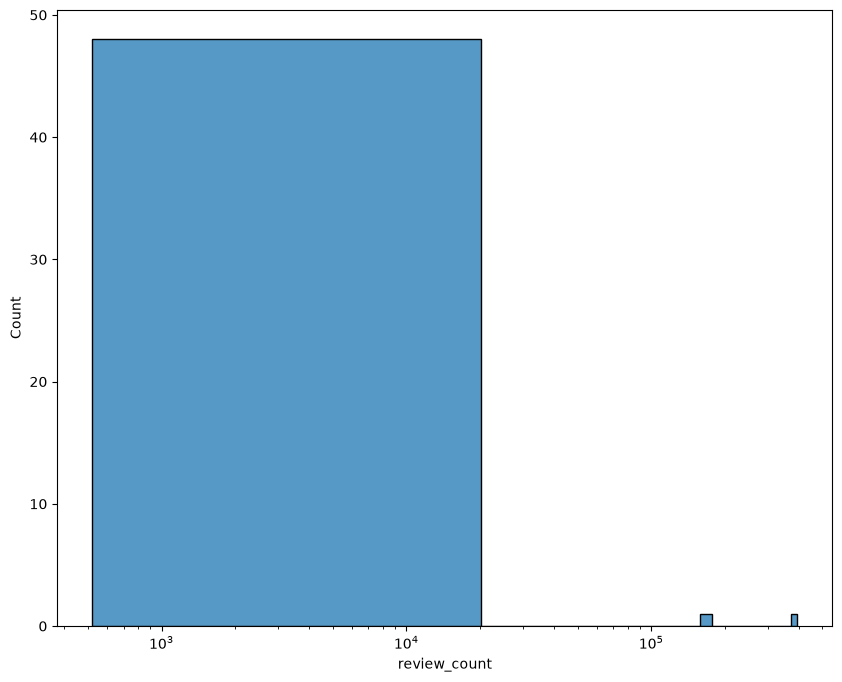

In [118]:
plt.figure(figsize=(10, 8))
sns.histplot(data = games_df, x = 'review_count', bins=20)
plt.xscale('log')

In [119]:
games_df['review_count'].describe()

count        50.000000
mean      13670.020000
std       59941.105406
min         522.000000
25%         812.750000
50%        1593.000000
75%        3231.250000
max      393378.000000
Name: review_count, dtype: float64

The distribution of `review_count` is very skewed, with only a small number of games having substantially higher reviews than the majority of games in the dataset. The most popular game, `Stardew Valley`, has a `review_count` of `393378` compared to a median of `1593`. This large difference demonstrates why a logarithmic scale will be useful when analysing `review_count`. 

<Figure size 640x480 with 0 Axes>

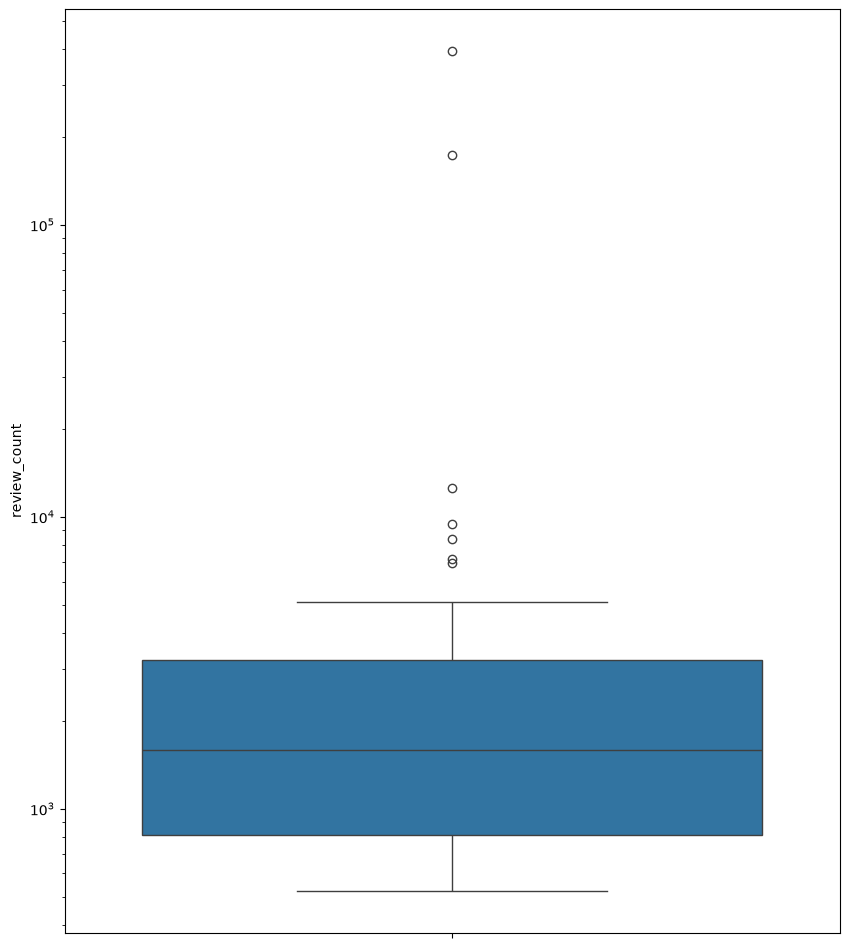

In [120]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.boxplot(data = games_df, y = 'review_count')
plt.yscale('log')

The boxplot displays that the majority of games have a relatively low `review_count` in comparison to the few outliers that are pulling up the `mean` of the dataset. I will therefore use log to make visualisations more interpretable and I will use the `median` as opposed to the `mean` for analyses as it will give a more honest representation of the average. 

### price vs popularity

To begin the EDA I will see if there is a relationship between the price of a game and its popularity. I will use the variable`price_GBP` and compare it against our target variable `review_count`, which is being used as a measure of popularity. Since `review_count` is highly skewed, I will continue using a log scale on the y axis to make the visualisations more interpretable. 

The rho is 0.018753503873938232, the p value is 0.8971483038739051


<Figure size 640x480 with 0 Axes>

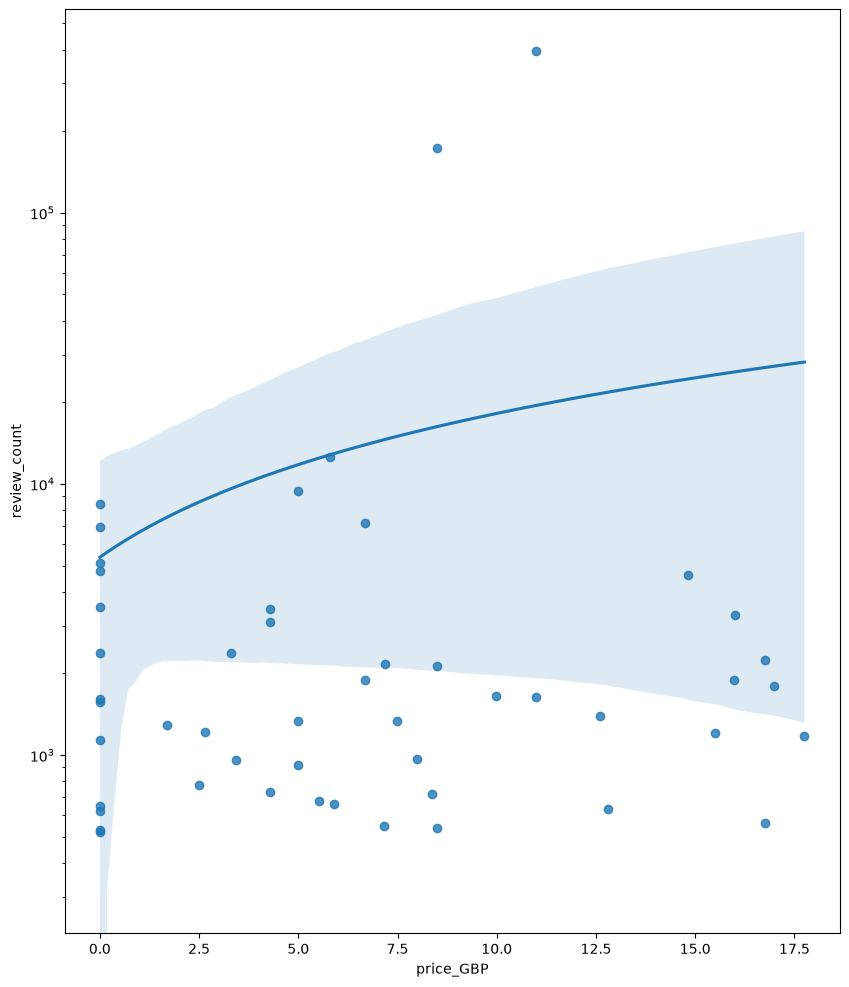

In [121]:
plt.clf()
plt.figure(figsize=(10, 12))
sns.regplot(data = games_df, x='price_GBP', y='review_count')
plt.yscale('log')

rho, p_value = spearmanr(games_df['price_GBP'], games_df['review_count'])
print("The rho is {}, the p value is {}".format(rho, p_value))


Although the most popular games are priced between `~£8 and ~£11`, popular games are found across the entire dataset with a including free-to-play games. This is supported by the spearman's correlation of `0.0188`, indicating that there is virtually no relationship between price and popularity in the top 50 most-reviewed games on Steam. 

### release_date vs popularity

The rho is -0.2975412988448037, the p_value is 0.035860349980343535


<Figure size 640x480 with 0 Axes>

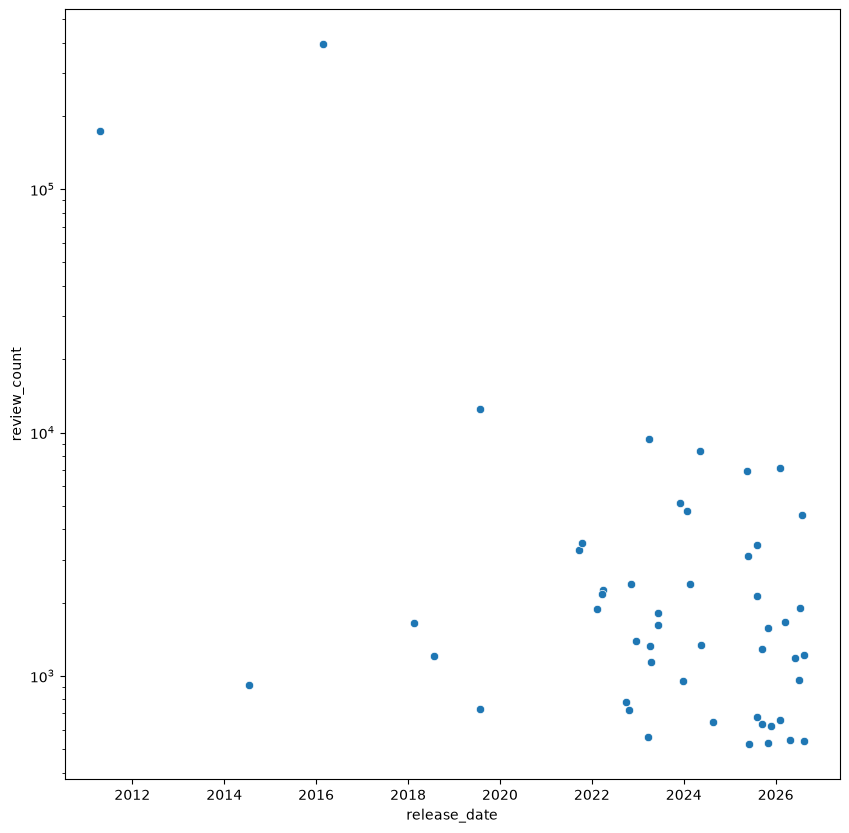

In [122]:
plt.clf()
plt.figure(figsize=(10, 10))
sns.scatterplot(data=games_df, x = 'release_date', y = 'review_count')
plt.yscale('log')

rho, p_value = spearmanr(games_df['release_date'].astype(int), games_df['review_count'])

print("The rho is {}, the p_value is {}".format(rho, p_value))

The scatterplot suggests that games with an earlier release date tend to have a higher number of reviews. This is supported by the results of the spearman's correlation (`ρ = -0.298, p_value = 0.0359`), pointing towards a relatively weak negative association that is statistically significant. However, this relationship is to be expected as older games have had more time to accumulate reviews. 


### review_score vs review_count

In [123]:
games_df['review_score'].unique()

array(['Overwhelmingly Positive'], dtype=object)

`Overwhelmingly Positive` is the only value, so this feature does not contain any variation. It therefore cannot be used to distinguish any differences in popularity within the sample set. 

### genre vs review_count

Next, I will investigate whether there is an association between the genre that a game belongs to and its popularity. Given that games can belong to multiple genres (eg a game might be listed as both `action` and `indie`), I will first use `split()` and `explode` so that each genre that a game belongs to is listed as its own observation. I can then use `value_counts()` to view the distribution of genres and `groupby()` and `agg()` to view the median number of reviews for each genre. This will allow me to compare the popularity of games across different genres. 

In [124]:
# create genre df
genre_df = games_df.assign(genre = games_df['genres'].str.split(', '))
genre_df = genre_df.explode('genre')
print("unique values in genre before filtering")
print(genre_df['genre'].unique())

# categories are repeated such as 'indie' and 'indie games'. I will filter the 'games' from the end
genre_df = genre_df[~genre_df['genre'].str.endswith(' Games')]

print("Unique values after filtering")
print(genre_df['genre'].unique())

unique values in genre before filtering
<StringArray>
[       'Indie Games',          'Adventure',              'Indie',
             'Action',             'Casual',           'Strategy',
       'Free To Play',     'Strategy Games',         'Simulation',
 'Free To Play Games',    'Adventure Games',   'Simulation Games',
          'RPG Games',                'RPG',       'Casual Games',
       'Action Games', 'Early Access Games',       'Early Access',
             'Sports']
Length: 19, dtype: str
Unique values after filtering
<StringArray>
[   'Adventure',        'Indie',       'Action',       'Casual',
     'Strategy', 'Free To Play',   'Simulation',          'RPG',
 'Early Access',       'Sports']
Length: 10, dtype: str


Now I will use `value_counts()` to view the distribution of games across different genres.

genre
Indie           39
Casual          29
Adventure       26
Action          14
Free To Play    10
Simulation       9
RPG              8
Strategy         6
Early Access     1
Sports           1
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

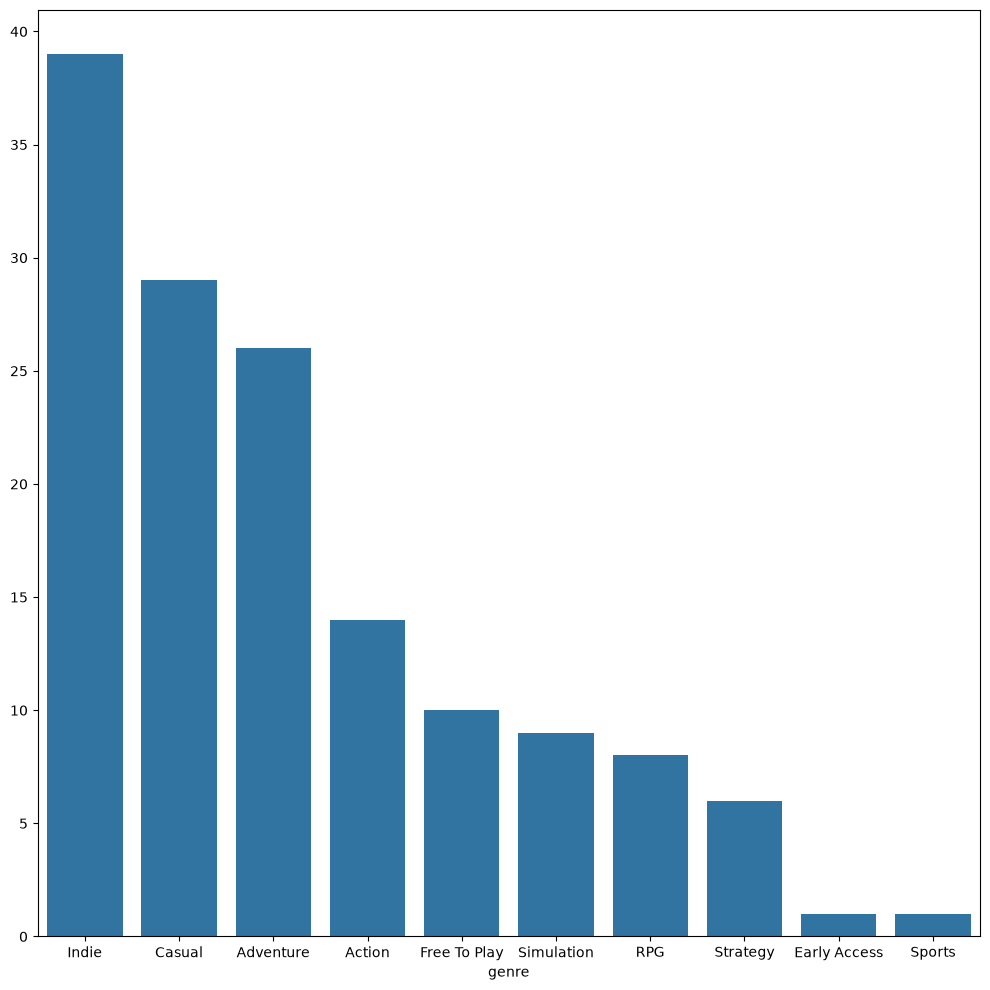

In [125]:
genre_counts = genre_df['genre'].value_counts()
print(genre_counts)

plt.clf()
plt.figure(figsize=(10, 10))
sns.barplot(x = genre_counts.index, y = genre_counts.values)
plt.tight_layout()



The above chart shows the distribution of different genres within the dataset. `Indie` is the most popular with `39` titles, followed by `Casual` with `29`, `Adventure` with `26` and `Action` with `14`. The genres `Early Access` and `Sports` only appear once in the dataset, so should not be used to compute the median. I will therefore filter the database to genres with more than `5` titles in the subsequent analysis. 

These counts represent genre assignments as opposed to unique games, which is why they do not sum to 50. 

              count  median
genre                      
Strategy          6  2671.0
Free To Play     10  2541.5
RPG               8  2449.0
Adventure        26  1848.5
Indie            39  1804.0
Casual           29  1657.0
Simulation        9  1574.0
Action           14  1487.5


<Figure size 640x480 with 0 Axes>

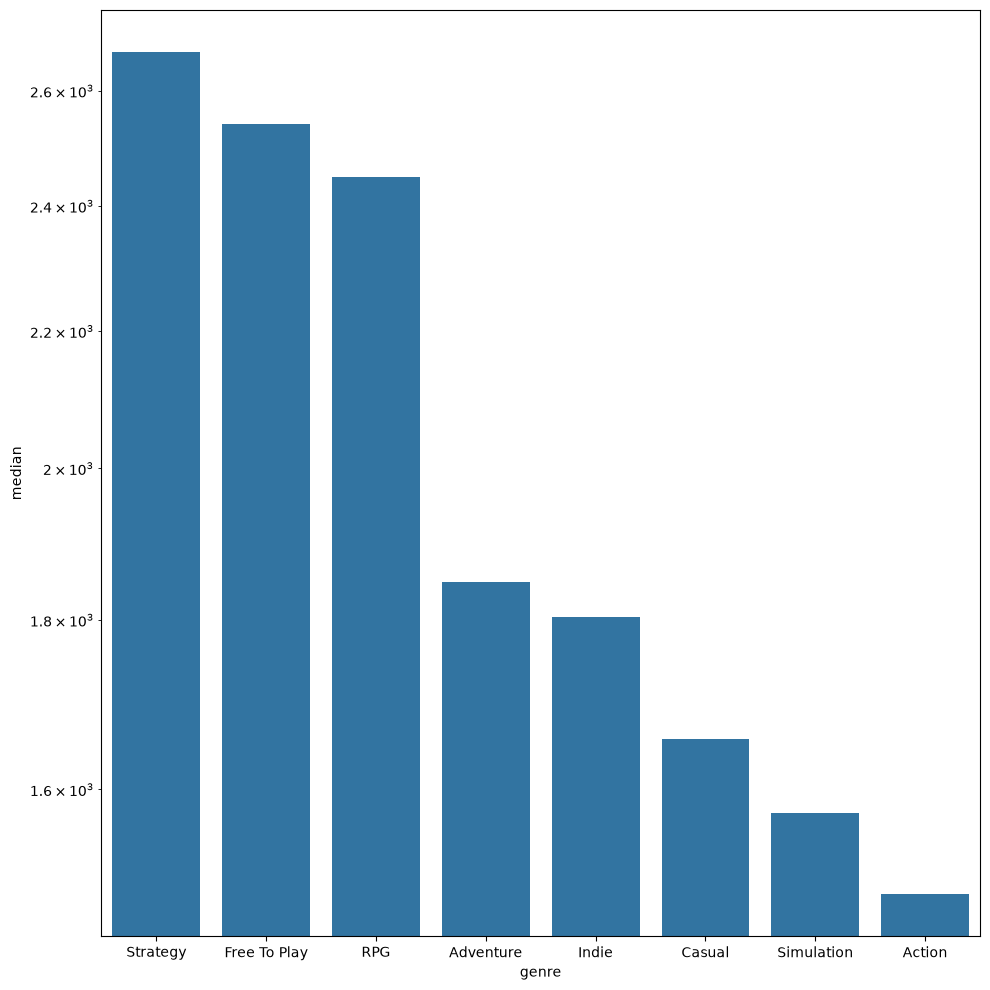

In [126]:
genre_median = genre_df.groupby('genre')['review_count'].agg(['count', 'median']).query('count >= 5').sort_values(by='median', ascending=False)
print(genre_median)

plt.clf()
plt.figure(figsize=(10, 10))
sns.barplot(x = genre_median.index, y = genre_median['median'])
plt.yscale('log')
plt.tight_layout()

`Strategy` has the highest popularity with a `review_count` of`2671.0` followed by `Free To Play` with a score of `2541.0`. `Action` games have the lowest `review_count` at `1487.5`. However, the difference in popularity between genres is still quite small and some genres have much smaller sample sizes than others, making the results unreliable. Therefore, while `genre` may be associated with popularity, these results alone do not provide strong evidence of a meaningful difference between genres when considering their popularity. 

### platforms vs review_counts

Finally, I will investigate whether the platforms that a game caters to are associated with a game's popularity. I will again begin by using `value_counts()` to view the distribution of the platforms, and then use `group_by()` and `agg()` to view the median review scores for each platform. This will help me to identify whether different platforms are associated with a game's popularity. 

platforms
win                23
win, mac, linux    12
win, mac            9
win, linux          6
Name: count, dtype: int64


<Axes: xlabel='platforms'>

<Figure size 640x480 with 0 Axes>

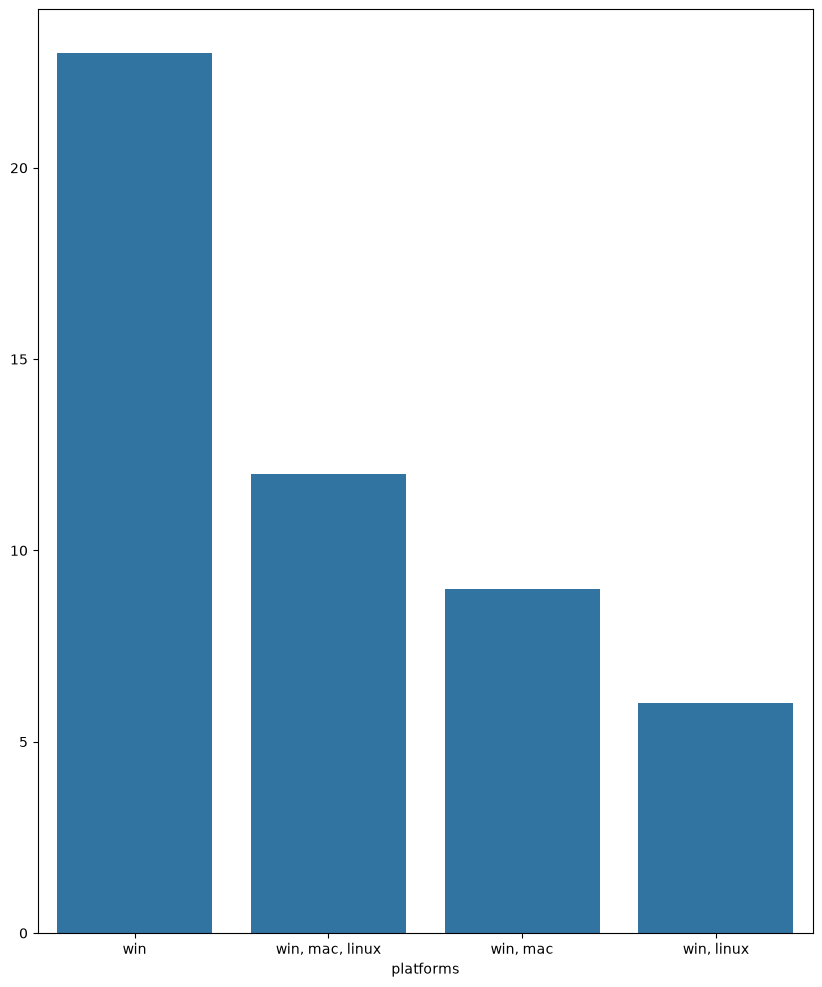

In [127]:
platform_counts = games_df['platforms'].value_counts().sort_values(ascending=False)
print(platform_counts)
plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = platform_counts.index, y = platform_counts.values)

platforms
win                22
win, mac, linux    12
win, mac           10
win, linux          6
Name: count, dtype: int64

`Win` (Windows) is the most popular platform having a count of `23`, followed by `win, mac, linux` with a count of `12`. `9` games are listed as being available for `win, mac` and only `6` games are available for `win, linux`. Every title is available for windows, but for the other platforms the availability differs significantly across the dataset.

                 count  median
platforms                     
win, mac, linux     12  1952.5
win                 23  1574.0
win, linux           6  1474.0
win, mac             9  1215.0


<Figure size 640x480 with 0 Axes>

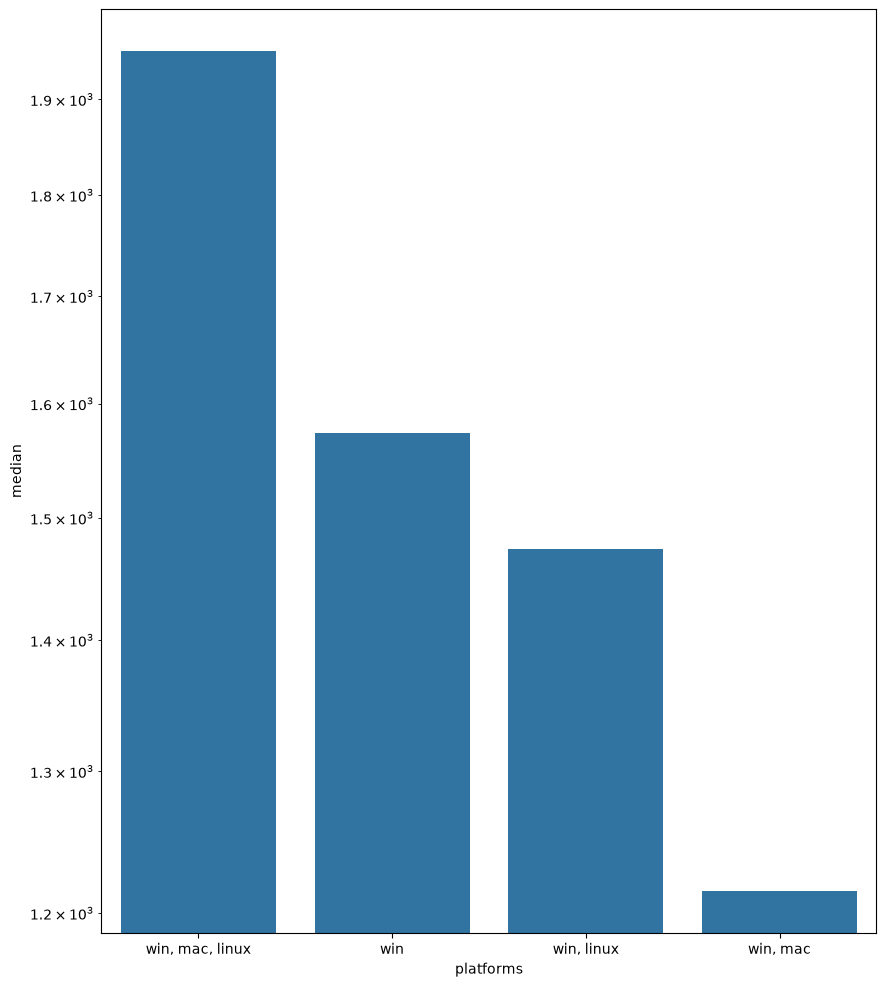

In [128]:
platforms_median = games_df.groupby('platforms')['review_count'].agg(['count', 'median']).sort_values(by='median', ascending=False)
print(platforms_median)

plt.clf()
plt.figure(figsize=(10, 12))
sns.barplot(x = platforms_median.index, y = platforms_median['median'])
plt.yscale('log')

The results show that titles available for `win, mac, linux` are the most popular, having a median `review_count` of `1952.5`. Titles only available for `win` are the second most popular, with a median count of `1574`, followed by `win, linux` with a median of `1474` and `win, mac` with a median of `1215`.\
The results indicate that games supporting all three platforms have the highest popularity, which makes sense given that they would have a larger audience. With that said however, the relatively small sample sizes means that these results should be interpreted with caution.

## Limitations and Conclusion

### Limitations

There are several limitations that are important to consider when interpreting the results from the analysis.

Firstly, the dataset contains a small sample size of only 50 games, that are taken from the Steam search engine and already ordered by review count. This means that there is an inherent bias to the dataset as the collection of games were not randomly selected from Steam. This means that the results of the analysis should not be generalised to the rest of the Steam marketplace. 

Secondly, `review_count` is being used as a proxy for popularity. While the number of reviews a game receives is likely to point towards it being more popular and the player base being more engaged, not every player leaves a review. There's also the possibility that review behaviour differs across different games and audiences. 

`Release_date` is also another important limitation. The analysis showed a statistically significant negative correlation between the release date of a game and the number of reviews it receives, but older games have had more time to receive reviews. Therefore, this association should not be interpreted as evidence that older games are more popular than newer games.

It's also important to consider the different sizes of the categorical variables. Given that this is a small dataset of only 50 games, categorical variables with relatively small sample sizes are not reliable for interpreting the median. 

Finally, it's important to note that this analysis does not identify causal relationships, but only associations. There are a lot of potential confounding variables that could influence the popularity of a game such as marketing, graphics quality, release timing or the reputation of the developer for example. The results therefore cannot directly establish that any of the discovered associations lead to a game becoming popular. 